# APE12-Implementación de la Correlación de Pearson y ajuste del Modelo de Regresión Lineal Simple por Mínimos Cuadrados Ordinarios (OLS)-Grupo A

# Tarea 1

--- Análisis de Correlación de Pearson ---
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


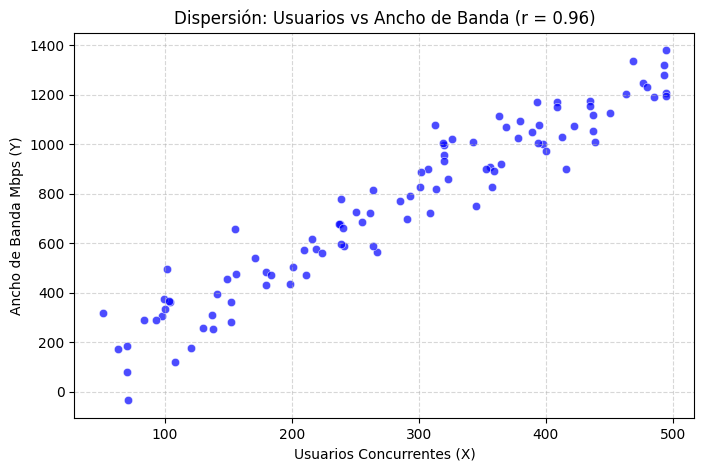

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)

# Y = 2.5*X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 1. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("--- Análisis de Correlación de Pearson ---")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
  print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
  print("Conclusión: NO existe evidencia de correlación lineal significativa.")

# Visualización: Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)
plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Tarea 2

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        02:25:30   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

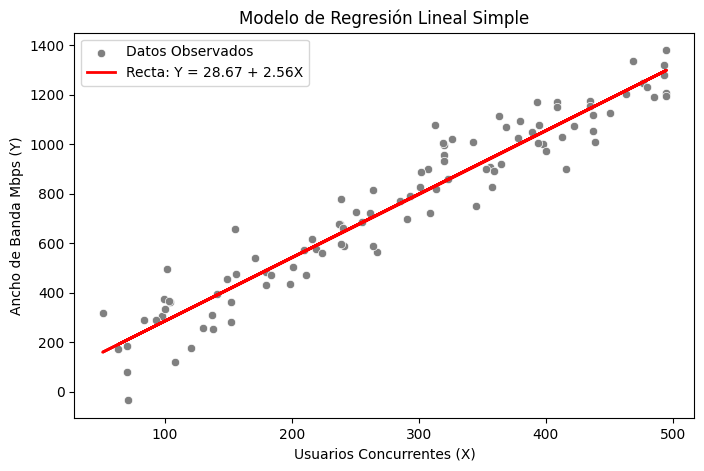

In [ ]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) al predictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')

# Dibujo de la recta de regresión
plt.plot(
    usuarios_X,
    beta_0 + beta_1 * usuarios_X,
    color='red',
    linewidth=2,
    label=f'Recta: Y = {beta_0:.2f} + {beta_1:.2f}X'
)
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()


# Tarea 3

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Variable Independiente (X): Cantidad (Número de acciones transaccionadas).
# Variable Dependiente (Y): Monto_Efectivo (Valor total de la operación en USD).

nombres = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio", "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]
df = pd.read_csv("BVG_Acciones_export.csv", names=nombres, skiprows=1)

df['Cantidad'] = pd.to_numeric(df['Cantidad'], errors='coerce')
df['Monto_Efectivo'] = pd.to_numeric(df['Monto_Efectivo'], errors='coerce')
df = df.dropna(subset=['Cantidad', 'Monto_Efectivo'])

# Cálculo de Correlación (r)
r = df['Cantidad'].corr(df['Monto_Efectivo'])

# Ajuste del Modelo OLS
X = df['Cantidad']
Y = df['Monto_Efectivo']
X_const = sm.add_constant(X)
modelo = sm.OLS(Y, X_const).fit()

# Coeficientes obtenidos
B0 = modelo.params['const']
B1 = modelo.params['Cantidad']

print(f"Coeficiente de Correlación (r): {r:.4f}")
print(modelo.summary())

# Predicción (Pronóstico Manual)
X_critico = 1000000
Y_esperado = B0 + (B1 * X_critico)

print("-" * 30)
print(f"PRONÓSTICO PARA X = {X_critico:,} acciones:")
print(f"El valor esperado de Y es: ${Y_esperado:,.2f} USD")


Coeficiente de Correlación (r): 0.9079
                            OLS Regression Results                            
Dep. Variable:         Monto_Efectivo   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                 1.366e+05
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        02:46:42   Log-Likelihood:            -3.5656e+05
No. Observations:               29131   AIC:                         7.131e+05
Df Residuals:                   29129   BIC:                         7.131e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6

### Se analiza la relación entre la 'Cantidad' (número de acciones transaccionadas) y el 'Monto_Efectivo' (valor total de la operación en USD).

### El R-cuadrado es de 0.824, lo que nos indica que el 82.4% de la variabilidad en el 'Monto_Efectivo' es explicada por la 'Cantidad' de acciones transaccionadas. Esto convierte a la 'Cantidad' en un predictor relevante del monto efectivo de la operación. Conocer la cantidad de acciones nos permite estimar el dinero que se moverá en una transacción, facilitando planificaciones financieras, estimaciones de montos de transacción e identificación de anomalías.

### En coef, la constante ('const') es de 6701.9950, lo que representa el monto de efectivo esperado cuando la cantidad de acciones transaccionadas es cero. Este valor podría interpretarse como un monto base asociado al inicio de una transacción o costos fijos mínimos. Por otro lado, el coef para 'Cantidad' es de 0.8095. Este valor indica que, por cada acción adicional transaccionada, el 'Monto_Efectivo' esperado aumenta en $0.8095 USD, lo cual establece el precio promedio por acción dentro de esta relación lineal.

### Los P-value (P>|t|) para 'const' y 'Cantidad' son ambos 0. Esto señala que existe una relación estadísticamente significativa y real entre la variable 'Cantidad' y la variable 'Monto_Efectivo', y que el intercepto ('const') es significativamente diferente de cero. El impacto del número de acciones transaccionadas en el monto efectivo de la operación es confiable y no puede atribuirse a la suerte o a fluctuaciones aleatorias en los datos.

Estadístico de Shapiro-Wilk: 0.0922
Valor P (p-value): 0.0000
Dictamen: Se rechaza Ho. Los residuos NO son normales.


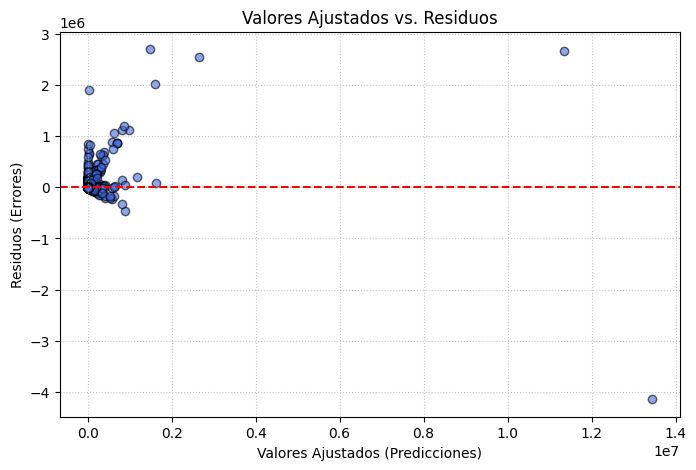

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

# Ejecución del test de Shapiro-Wilk sobre los residuos del modelo

# Ho: Los errores siguen una distribución normal
# H1: Los errores no siguen una distribución normal
shapiro_stat, shapiro_p = stats.shapiro(modelo.resid)

print(f"Estadístico de Shapiro-Wilk: {shapiro_stat:.4f}")
print(f"Valor P (p-value): {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Dictamen: No se rechaza Ho. Los residuos son normales.")
else:
    print("Dictamen: Se rechaza Ho. Los residuos NO son normales.")


# Generación del gráfico de diagnóstico: Valores Ajustados vs. Residuos
plt.figure(figsize=(8, 5))
plt.scatter(modelo.fittedvalues, modelo.resid, color='royalblue', edgecolors='k', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--') # Línea de referencia en cero

plt.title("Valores Ajustados vs. Residuos")
plt.xlabel("Valores Ajustados (Predicciones)")
plt.ylabel("Residuos (Errores)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


### Se establece, por el test de Shapiro-Wilk, que los residuos no siguen una distribución normal. Al tener un valor p menor a 0.05, las inferencias del modelo podrían ser engañosas o no tan confiables.
### En el gráfico de "Valores Ajustados vs. Residuos" se observa un patrón no aleatorio, con forma de embudo. Esto indica que la dispersión de los errores es pequeña para valores de predicción bajos, pero muy grande cuando se trata de valores altos. Así, con montos bajos, el modelo es preciso y tiene pocos errores, pero con montos altos, genera incertidumbre y errores considerablemente mayores.
### La presencia de este patrón significa que no hay homocedasticidad. Por lo tanto, las estimaciones del modelo no son fiables, y las conclusiones derivadas de ellas tampoco.
### Además, se detectan valores atípicos que provocan que el modelo se equivoque en ciertas predicciones, lo que sugiere la existencia de datos erróneos o variables omitidas.
### Por consiguiente, podemos concluir que el modelo generado presenta limitaciones significativas, especialmente en lo que respecta a grandes transacciones. No se puede confiar plenamente en sus estimaciones. Se podrían considerar otros modelos, investigar más a fondo el conjunto de datos por si se omitió información relevante, o aplicar transformaciones a las variables para estabilizar los datos.